# Import utils

In [79]:
from utils.classification_utils import ClassifierPreprocessor
from utils.dataset_utils import SegmentDatasetAllTimestamps

In [80]:
machine_part ="movement"

# Create my own classifier class

In [81]:
classifier_preprocessor = ClassifierPreprocessor(sensors_path=f"../../../../data/ml/features_{machine_part}_complete.csv", annotation_json="../../../../data/ml/machine-and-movement_complete.json")

In [82]:
import json

with open("../../../../data/ml/unique_experiment_ids.json", "r") as f:
    experiment_groups = json.load(f)
    
Label="Clamping"
# Label="Mandrel Extraction"

# Read and Preprocess for training

In [83]:
sensors_df, annotation_dict = classifier_preprocessor.read_data()
#sensors_df = classifier_preprocessor.feature_selection()
sensors_df = classifier_preprocessor.assign_one_label(target_label=Label) # Clamping, De-Clamping, Mandrel Extraction
sensors_df = classifier_preprocessor.normalize_and_encode_labels()

# Create the Dataloader

In [84]:
from torch.utils.data import DataLoader
batch_size = 64
train_df, val_df, test_df, experiment_ids = classifier_preprocessor.split_experiments(experiment_groups=experiment_groups)
train_dataset, val_dataset, test_dataset = classifier_preprocessor.create_datasets(
    train_df, val_df, test_df, SegmentDatasetAllTimestamps
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train experiment IDs (209): [4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19, 26, 27, 30, 31, 32, 33, 36, 37, 38, 39, 41, 42, 44, 49, 50, 55, 56, 57, 58, 59, 62, 63, 64, 66, 67, 68, 70, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 84, 86, 88, 89, 90, 91, 92, 94, 95, 96, 97, 98, 101, 102, 104, 106, 107, 108, 109, 111, 113, 115, 116, 117, 129, 132, 133, 135, 137, 138, 139, 140, 141, 143, 144, 145, 146, 147, 148, 149, 152, 155, 156, 157, 159, 160, 161, 162, 163, 165, 167, 168, 169, 170, 171, 173, 174, 175, 176, 177, 180, 181, 184, 185, 188, 189, 190, 191, 192, 199, 200, 201, 202, 203, 204, 208, 209, 210, 214, 215, 216, 217, 218, 219, 220, 221, 222, 226, 227, 228, 229, 230, 231, 235, 236, 237, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 256, 257, 259, 260, 262, 263, 264, 265, 266, 267, 268, 269, 270, 274, 275, 276, 277, 278, 279, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 

# Create the model and train

In [85]:
feature_cols = classifier_preprocessor.get_feature_cols()
input_size = len(feature_cols)
hidden_size = 64
num_layers = 2
num_classes = len(train_dataset.unique_labels)

In [86]:
import torch
from utils.model import LSTMClassifier
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(input_size, hidden_size, num_layers, num_classes, bidirectonal=True).to(device)

In [87]:
if machine_part == "movement":
    machine_part ="movements"
model_path = f"../../../../models/classifier/{machine_part}/{Label}"

In [ ]:
model.train_model(
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=100,
    learning_rate=1e-4,
    patience=3,
    device=device,
    model_path=model_path,
    run_name=Label,
    experiment_name="Classifier_M"
)

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100:   0%|          | 0/5154 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/5154 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/5154 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/5154 [00:00<?, ?it/s]

Epoch 5/100:   0%|          | 0/5154 [00:00<?, ?it/s]

Epoch 6/100:   0%|          | 0/5154 [00:00<?, ?it/s]

# Load and Evaluate the Model

In [ ]:
import joblib
state_dict = joblib.load(f"{model_path}/Activity_Detector.joblib")
model.load_state_dict(state_dict)
model.eval()

LSTMClassifier(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

# Vizualize the Prediction

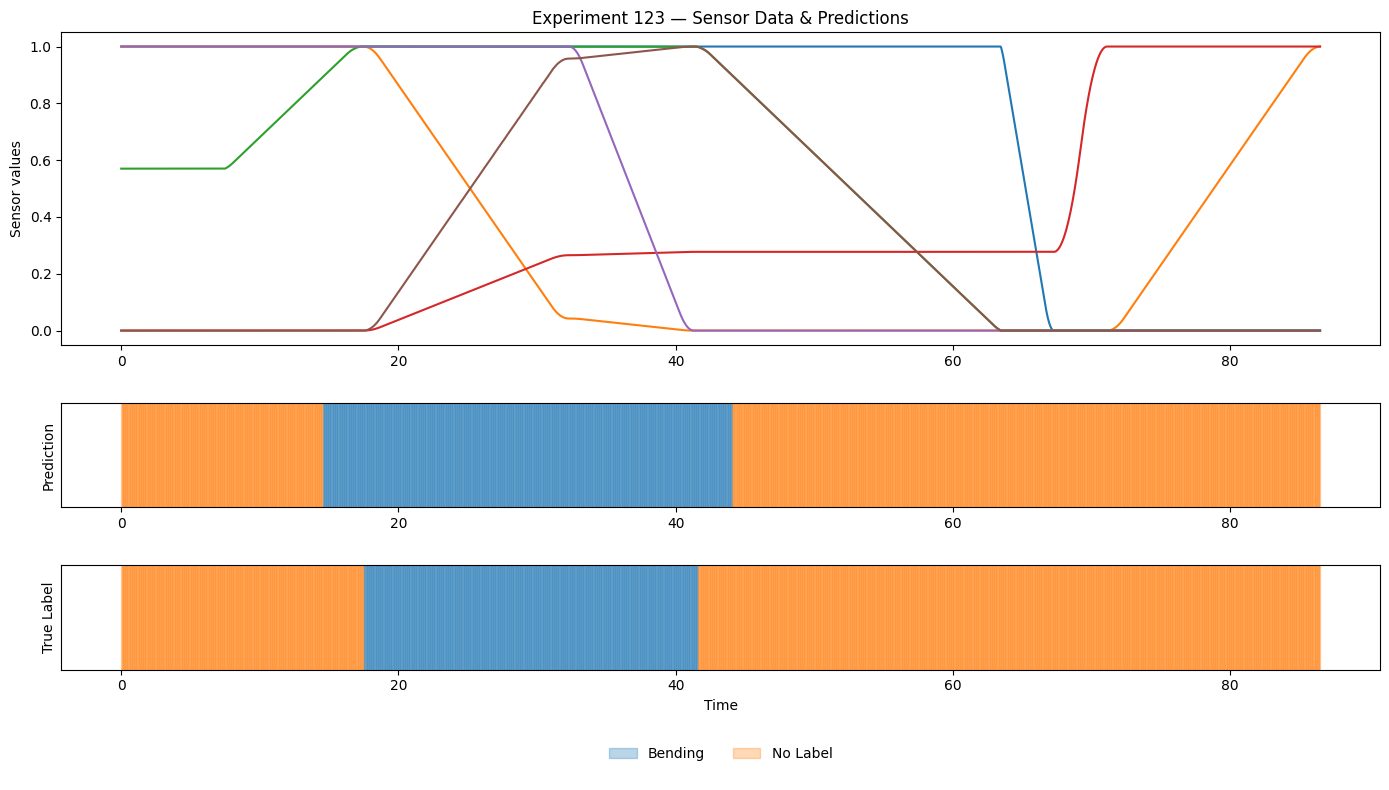

In [ ]:
from utils.plot_utils import plot_predictions_vs_true_annot
experiment_ids = [2, 3, 22, 23, 40, 54, 83, 85, 110, 112, 119, 120, 121, 122, 123, 178, 179, 182, 183, 211, 212, 213, 255, 258, 261, 271, 272, 273, 302, 303, 304, 317, 318]
plot_predictions_vs_true_annot(model, test_dataset, sensors_df, feature_cols, experiment_ids)

In [ ]:
# df = sensors_df[(sensors_df["Label"] == "Bending") | (sensors_df["Label"] == "Mandrel Extraction")].drop(columns=["Label_encoded", "Label"])
# df.to_csv("../../../../data/ml/bending_features.csv")
# df = sensors_df[(sensors_df["Label"] == "Clamping")].drop(columns=["Label_encoded", "Label"])
# df.to_csv("../../../../data/ml/clamping_features.csv")
# df = sensors_df[(sensors_df["Label"] == "De-Clamping")].drop(columns=["Label_encoded", "Label"])
# df.to_csv("../../../../data/ml/declamping_features.csv")